# EIGSEP Image Fit

Aaron Parsons

In [1]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib.image import imread
import torch
# from transformers import pipeline
from eigsep_terrain.marjum_dem import MarjumDEM as DEM
from eigsep_terrain.img import HorizonImage, PRM_ORDER
# from eigsep_data.plot import terrain_plot
import healpy
import pymc as pm
import pytensor
pytensor.config.cxx = ""
import pytensor.tensor as pt
from pytensor.compile.ops import as_op
import os, sys, glob, tqdm
import multiprocessing as mp
import arviz, corner

%matplotlib widget

In [2]:
CACHE_FILE = 'marjum_dem.npz'
dem = DEM(cache_file=CACHE_FILE)

In [3]:
dem['platform'] = np.array([1648, 2024, 1796])

meta = {}
meta['0817'] = {
    'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0378]
    'ant_px': (2*1366, 2*1221),
}
meta['0833'] = {
    'best_prms': ( 1611.38,  1847.62,   1659.85,  1.2062,  1.2401, -0.0250,  5072.38),  #[LOSS= 0.0254]
    'ant_px': (1606, 2700),
}

#meta['0834'] = {
#    'best_prms': ( 1642.45,  1887.80,   1678.94,  1.1787,  1.2417, -0.0310,  2933.66),  #[LOSS= 0.0685]
#    'ant_px': (1622, 2251),
#}

meta['0860'] = {
    #'best_prms': ( 1539.90,  1989.78,   1765.54,  1.5423,  0.6162,  0.1541,  2328.29),  #[LOSS= 0.0206]
    #'best_prms': ( 1538.80,  2001.28,   1765.46,  1.5411,  0.6109,  0.1589,  2328.29),  #[LOSS= 0.0166]
    'best_prms': ( 1540.51,  1998.55,   1766.85,  1.5421,  0.6131,  0.1584,  2328.30),  #[LOSS= 0.0151]
    'ant_px': (2924, 1945),
}

for k in meta.keys():
    dem[k] = np.asarray(meta[k]['best_prms'][:3], dtype=np.float32)
    
files = sorted(glob.glob('//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/*.jpg'))
#files = sorted(glob.glob('/home/aparsons/Downloads/IMG_08*.jpg'))[-1:]
print(files)
imgs = [HorizonImage(f, meta) for f in files]
imgs = [img for img in imgs if img.key in meta]


['//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0817.jpg', '//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0833.jpg', '//Users/komalkaur/Desktop/eigsep_stuff/hrzn_mapping/imgs/IMG_0860.jpg']


In [4]:
dem.interp_alt(imgs[-1].prms['e'], imgs[-1].prms['n'])


np.int32(1758)

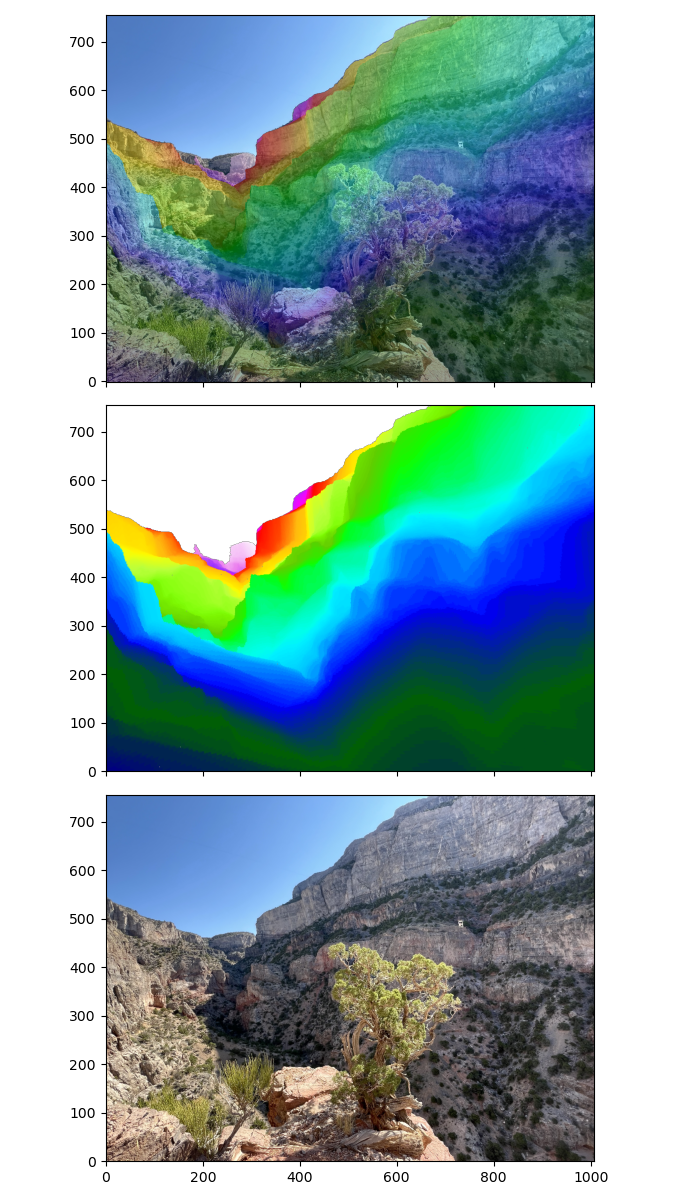

In [5]:
# overlay ray tracing

if True:
    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(7, 4 * 3))
    r_imgs = {}
    sl = slice(None, None, 4)
    img = imgs[-1]
    axes[0].imshow(img.img[sl,sl], origin='lower')
    axes[2].imshow(img.img[sl,sl], origin='lower')
    r_imgs[img.key] = img.ray_distance(dem, img.get_rays()[...,sl,sl])
    axes[1].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar')
    axes[0].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar', alpha=0.4)
    plt.tight_layout()


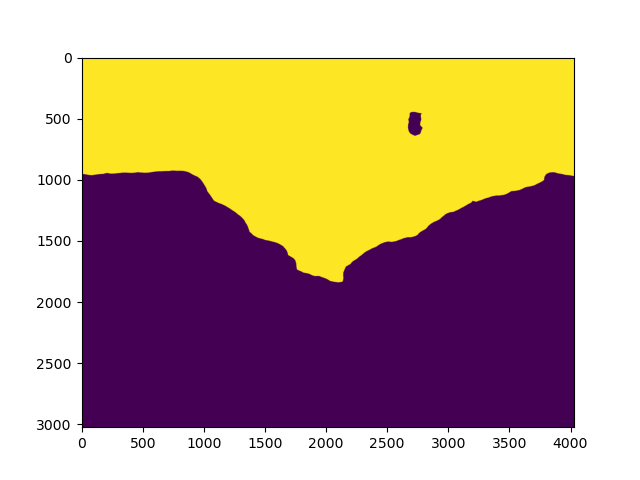

In [6]:
i = imgs[0]
npz = np.load(i.npzfile)
plt.figure()
plt.imshow(npz['sky'])


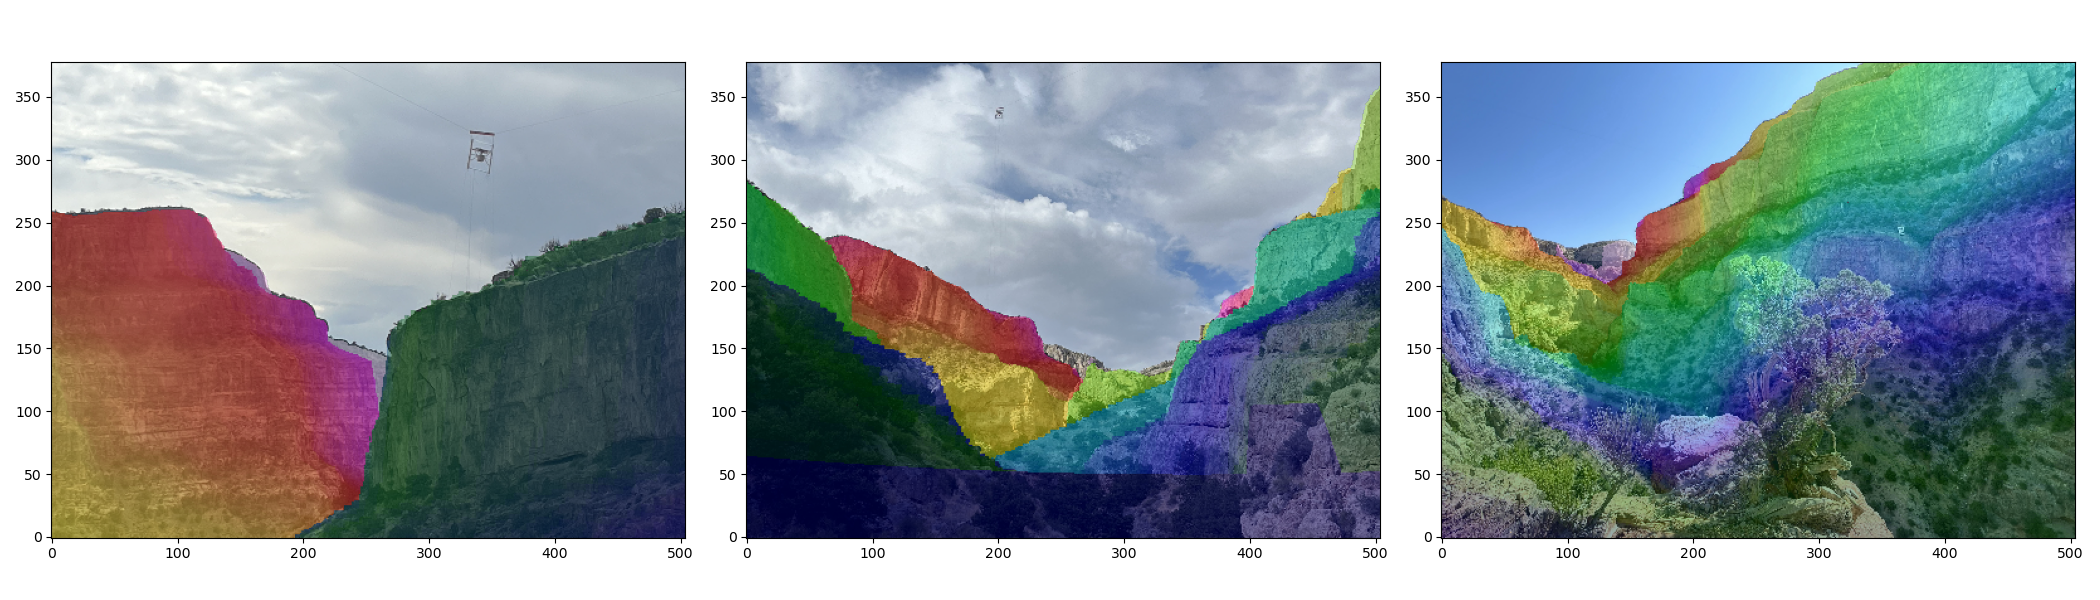

In [7]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    r_imgs = {}
    sl = slice(None, None, 8)
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img[sl,sl], origin='lower')
        r_imgs[img.key] = img.ray_distance(dem, img.get_rays()[...,sl,sl])
        axes[cnt].imshow(r_imgs[img.key], origin='lower', cmap='gist_ncar', alpha=0.4)
    plt.tight_layout()

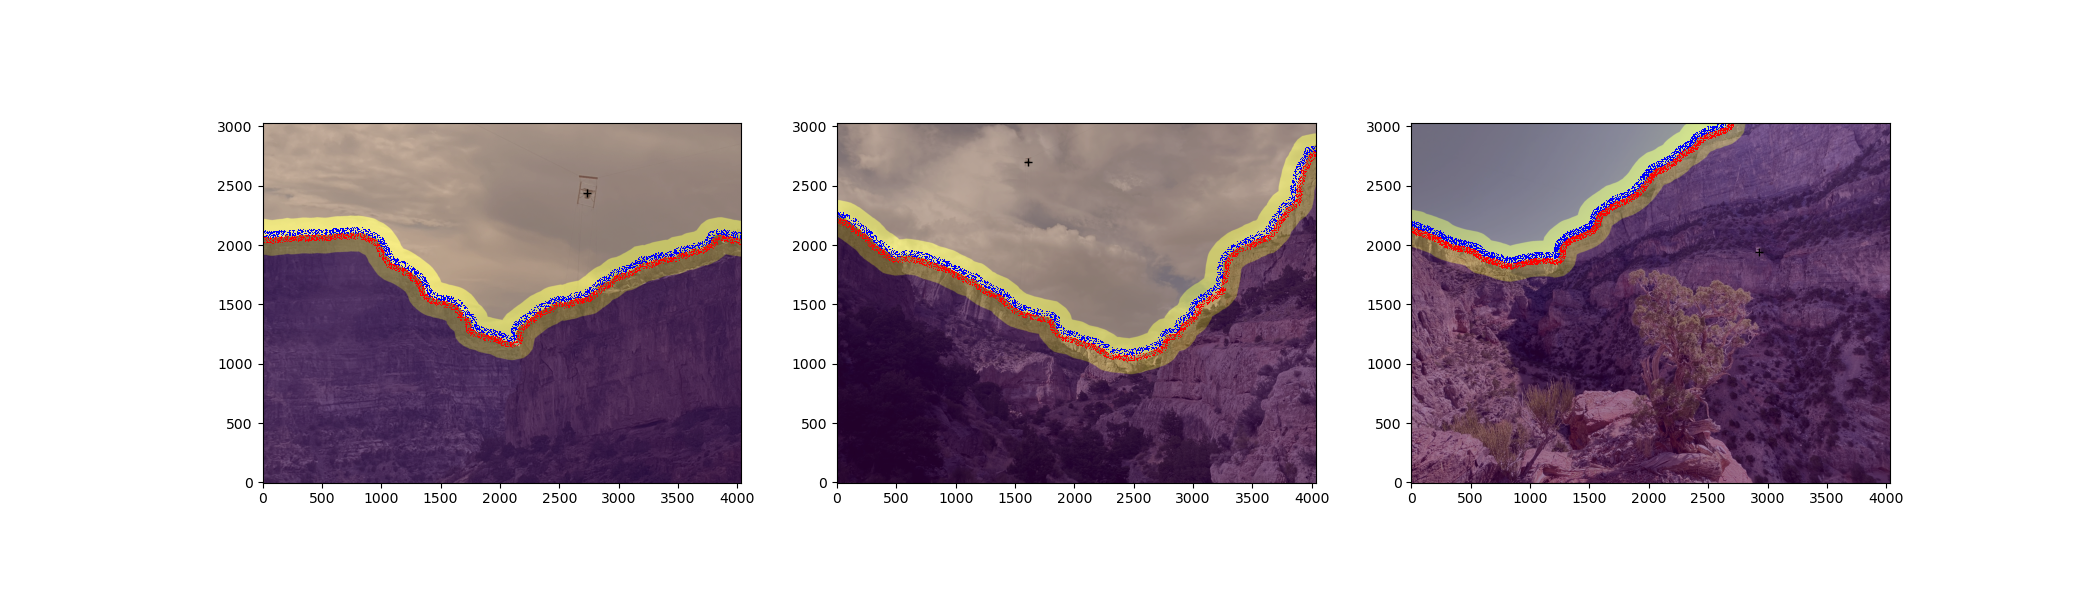

In [8]:
if True:
    fig, axes = plt.subplots(ncols=len(imgs), figsize=(7 * len(imgs), 6))
    if len(imgs) == 1:
        axes = [axes]
    for cnt, img in enumerate(imgs):
        axes[cnt].imshow(img.img, origin='lower')
        axes[cnt].imshow(img.sky_mask, origin='lower', alpha=0.3)
        axes[cnt].imshow(img.horizon_mask, origin='lower', alpha=0.3)
        mask = img.mask_near_horizon(50)
        x, y = img.choose_pixels(mask=mask, N=16000//3)
        is_sky = img.sky_mask[x, y]
        axes[cnt].plot(y[is_sky], x[is_sky], 'b,')
        axes[cnt].plot(y[~is_sky], x[~is_sky], 'r,')
        axes[cnt].plot(*img.meta['ant_px'], 'k+')

In [9]:
#nside = 512
##e0, n0, u0 = (1754, 2100, 1747)
#e0, n0, u0 = start_point = np.array((1767, 2095, 1759), dtype=float)
#rays = et.ray.healpix_rays(nside)
##e0, n0, u0 = start_point = np.array(dem['1P'], dtype=float)
##e0, n0, u0 = (0, 0, 1759)

In [10]:
#healpy.mollview(h.map)
#healpy.mollview(np.log10(ray_trace(start_point)), cmap='plasma')
#healpy.mollview(np.log10(r), cmap='plasma')
#healpy.mollview(np.log10(r2), cmap='plasma')
#healpy.mollview(T[-1], cmap='plasma')
#healpy.mollview((T_sky_full[:, 180]), cmap='plasma')

In [11]:
# for one image

I = imgs[2]
I.reset_pixel_choice()
I.horizon_ray_loss(dem, cnt=16000);
ant_ray = I.get_rays(np.array(I.meta['ant_px'][::-1]))
prms = dict(zip(PRM_ORDER, I.get_prms()))
r_ant = dem['platform'] - np.array([prms['e'], prms['n'], prms['u']])

delta_theta = np.arccos(np.dot(ant_ray, r_ant) / (np.linalg.norm(ant_ray) * np.linalg.norm(r_ant))) # rad
BOX_SIZE = 0.3 # m
sigma_theta = BOX_SIZE / np.linalg.norm(r_ant)

logL = -delta_theta / (2 * sigma_theta**2) # :0
logL
                        

'best_prms': ( 1540.51,  1998.55,   1766.85,  1.5421,  0.6131,  0.1584,  2328.30),  #[LOSS= 0.0529]


np.float64(-8694.42794836528)

In [12]:
sigmas = (30.0, 30.0, 30.0, np.deg2rad(5.0), np.deg2rad(5.0), np.deg2rad(5.0), 0.1)
BOX_SIZE = 0.3 # m


def make_sigmas(imgs):
    return [img.prms[k] * sig if sig == 'f' else sig for k, sig in zip(PRM_ORDER, sigmas) for img in imgs]

def build_model(img, dem, n_rays, eps=0.01):
    """
    eps: per-pixel error rate for mismatches (small)
    """
    @as_op(itypes=[pt.dvector], otypes=[pt.fscalar])
    def horizon_mismatches_loss(theta):
        L = 0.0
        for cnt, img in enumerate(imgs):
            img.set_prms(tuple(theta[cnt*len(PRM_ORDER):(cnt+1)*len(PRM_ORDER)]))
            L += img.horizon_ray_loss(dem, cnt=n_rays)
        return np.array(L / len(imgs), dtype=np.float32)

    with pm.Model() as model:
        #TODO: priors
        prms = []
        sigmas = make_sigmas(imgs)
        for cnt, img in enumerate(imgs):
            _sigmas = sigmas[cnt*len(PRM_ORDER): (cnt+1)*len(PRM_ORDER)]
            prms += [pm.Normal(f"{img.key}_{k}", mu=img.prms[k], sigma=sig) for k, sig in zip(PRM_ORDER, _sigmas)]            
        theta = pt.stack(prms)
        L = horizon_mismatches_loss(theta)
        # logp = (N - L)*log(1-eps) + L*log(eps)
        logp = len(imgs) * n_rays * (1 - L) * np.log(1.0 - eps) + len(imgs) * n_rays * L * np.log(eps)
        for I in imgs:
            prior = np.array([1646, 2022, 1782])
            ant_ray = I.get_rays(np.array(I.meta['ant_px'][::-1]))
            prms = dict(zip(PRM_ORDER, I.get_prms()))
            r_ant = prior - np.array([prms['e'], prms['n'], prms['u']])
            
            delta_theta = np.arccos(np.dot(ant_ray, r_ant) / (np.linalg.norm(ant_ray) * np.linalg.norm(r_ant))) # rad
            sigma_theta = BOX_SIZE / np.linalg.norm(r_ant)
            
            logL = -delta_theta / (2 * sigma_theta**2) # :0
            print('logp', logp.eval())
            print('logL', logL)
            logp += logL
            
        pm.Potential("lik", logp)

    return model

In [13]:
if True:
    with build_model(I, dem, n_rays=16000, eps=0.01) as model:
        step = pm.DEMetropolisZ(
            S=np.array(make_sigmas(imgs)),
            scaling=0.01,      # much bigger than 1e-3, TODO: may need to tune this
            tune='scaling',   # let it adapt scale
            tune_interval=50, # adapt more often than default 100
        )
        
        trace = pm.sample(
            draws=500,
            tune=100,
            chains=4,
            step=step,
            cores=4,
            random_seed=42,
            progressbar=True,
        )
    arviz.to_netcdf(trace, f"{I.key}_trace.nc");
    print(f"Accepted step fraction = {float(trace.sample_stats.accepted.mean()): 4.3f}")
    # rejecting most steps = steps too big
    # accepting most steps = steps too small

'best_prms': ( 1804.30,  2076.39,   1775.78,  16.7420,  22.2297,  11.9374,  9909.75),  #[LOSS= 0.4923]
'best_prms': ( 1649.57,  1861.29,   1659.81,  1.2338,  1.1911, -0.2088,  5072.27),  #[LOSS= 0.5019]
logp -101331.51160895197
logL -1222.9644591741876
logp -102554.47606812615
logL -53956.96854641875
logp -156511.44461454492
logL -3831.755508996341


/Users/komalkaur/miniconda3/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [0817_e, 0817_n, 0817_u, 0817_th, 0817_ph, 0817_ti, 0817_f, 0833_e, 0833_n, 0833_u, 0833_th, 0833_ph, 0833_ti, 0833_f, 0860_e, 0860_n, 0860_u, 0860_th, 0860_ph, 0860_ti, 0860_f]


Output()

'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0374]


'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0374]
'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0374]
'best_prms': ( 1732.31,  2069.73,   1760.89,  1.4682,  3.6963, -0.0521,  9849.36),  #[LOSS= 0.0374]


...

'best_prms': ( 1611.38,  1847.62,   1659.85,  1.2061,  1.2401, -0.0249,  5072.38),  #[LOSS= 0.0514]


'best_prms': ( 1540.51,  1998.55,   1766.85,  1.5422,  0.6133,  0.1584,  2328.30),  #[LOSS= 0.0514]


'best_prms': ( 1611.38,  1847.65,   1659.85,  1.2062,  1.2402, -0.0250,  5072.38),  #[LOSS= 0.0514]


Sampling 4 chains for 100 tune and 500 draw iterations (400 + 2_000 draws total) took 1842 seconds.
/Users/komalkaur/miniconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Accepted step fraction =  0.000


In [16]:
trace_files = sorted(glob.glob("*.nc"))
print(trace_files)
traces = {f.split('_')[0]: arviz.from_netcdf(f) for f in trace_files}

['0860_trace.nc']


ValueError: It looks like the parameter(s) in column(s) 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20 have no dynamic range. Please provide a `range` argument.

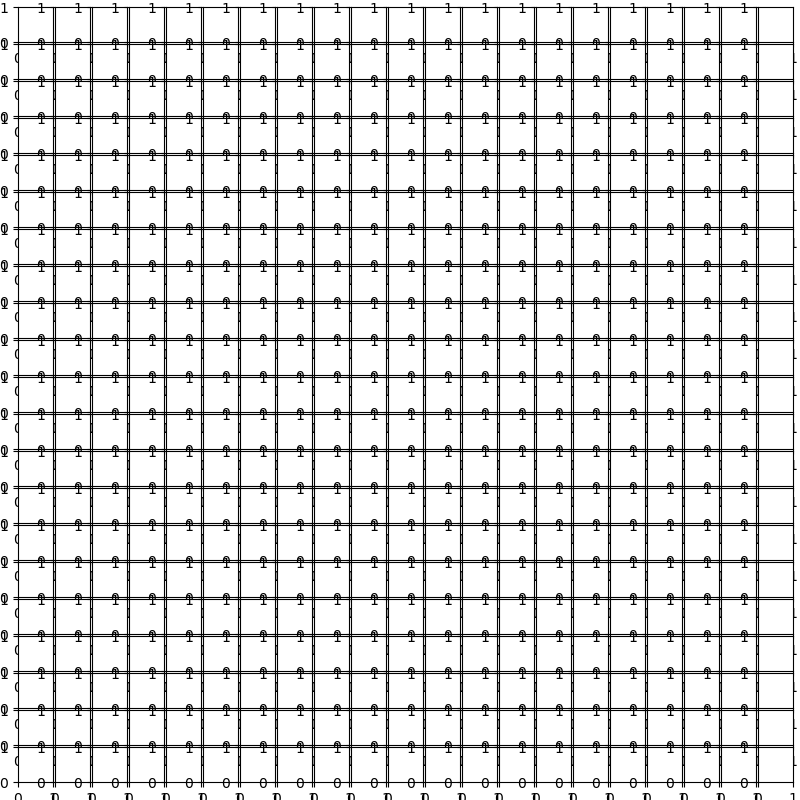

In [17]:
fig = plt.figure(figsize=(8, 8))
corner.corner(traces['0860'], fig=fig);

NameError: name 'terrain_plot' is not defined

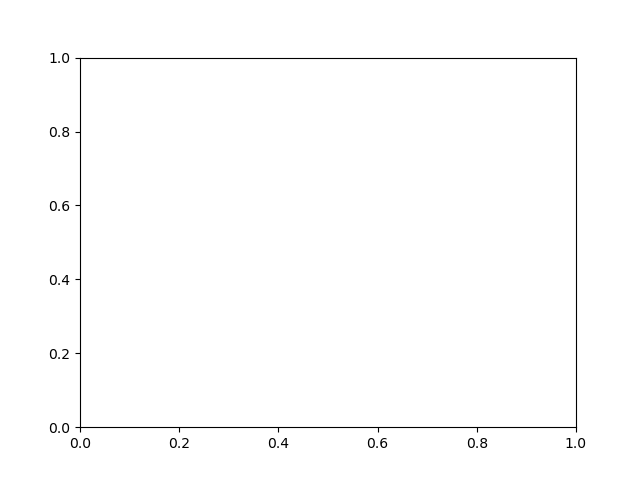

In [ ]:
#e,n,u = dem.latlon_to_enu(39.247907, -113.402715)
#u = dem.interp_alt(e, n)
#print(e, n, u)
fig, ax = plt.subplots()
e0, n0, u0 = dem['platform']
rng = 750
terrain_plot(dem, res=dem.res, ax=ax, vmin=u0-300, vmax=u0+200, erng_m=(e0-rng, e0+rng), nrng_m=(n0-rng, n0+rng))
plt.plot([e0], [n0], 's', color='k')
for img in imgs:
    e, n, u = img.prms['e'], img.prms['n'], img.prms['u']
    plt.plot([e], [n], '+', color='k')
    ant_ray = img.get_rays(pixels=np.array(img.meta['ant_px'][::-1]))
    plt.plot([e, e + ant_ray[0] * 220], [n, n + ant_ray[1] * 220], ':', color='k')
    trace = traces[img.key]
    try:
        plt.plot(np.asarray(trace.posterior[f'{img.key}_e']).flatten(), np.asarray(trace.posterior[f'{img.key}_n']).flatten(), '.');
    except(KeyError):
        plt.plot(np.asarray(trace.posterior['e']).flatten(), np.asarray(trace.posterior['n']).flatten(), '.');